# Imports

In [1]:
import torch
import numpy as np
import pandas as pd
from imoltance import Imoltance
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

import random

# Make Dataset

In [2]:
SEED = 42

# Python
random.seed(SEED)

# NumPy
np.random.seed(SEED)

In [3]:
imlt = Imoltance('Bradley_Melting_Point_Dataset.csv', 'SMILES', ['Tm'], 42)
imlt.run()

1 / 16447
2 / 16447
3 / 16447
4 / 16447
5 / 16447
6 / 16447
7 / 16447
8 / 16447
9 / 16447
10 / 16447
11 / 16447
12 / 16447
13 / 16447
14 / 16447
15 / 16447
16 / 16447
17 / 16447
18 / 16447
19 / 16447
20 / 16447
21 / 16447
22 / 16447
23 / 16447
24 / 16447
25 / 16447
26 / 16447
27 / 16447
28 / 16447
29 / 16447
30 / 16447
31 / 16447
32 / 16447
33 / 16447
34 / 16447
35 / 16447
36 / 16447
37 / 16447
38 / 16447
39 / 16447
40 / 16447
41 / 16447
42 / 16447
43 / 16447
44 / 16447
45 / 16447
46 / 16447
47 / 16447
48 / 16447
49 / 16447
50 / 16447
51 / 16447
52 / 16447
53 / 16447
54 / 16447
55 / 16447
56 / 16447
57 / 16447
58 / 16447
59 / 16447
60 / 16447
61 / 16447
62 / 16447
63 / 16447
64 / 16447
65 / 16447
66 / 16447
67 / 16447
68 / 16447
69 / 16447
70 / 16447
71 / 16447
72 / 16447
73 / 16447
74 / 16447
75 / 16447
76 / 16447
77 / 16447
78 / 16447
79 / 16447
80 / 16447
81 / 16447
82 / 16447
83 / 16447
84 / 16447
85 / 16447
86 / 16447
87 / 16447
88 / 16447
89 / 16447
90 / 16447
91 / 16447
92 / 164

# Import and Preprocess Data

In [12]:
train_data_df = pd.read_csv('imoltance_dump/train_features.csv')
test_data_df = pd.read_csv('imoltance_dump/test_features.csv')

In [13]:
X_train = train_data_df[[
                        'M1_alpha_ve', 'M1_beta_ve', 'M2_ve', 'R_ve', 'ABC_ve', 'GA_ve',
                        'H_ve', 'X_ve', 'HM1_ve', 'HM2_ve', 'F_ve', 'F1_ve',
                        'ReZG3_ve', 'AG_ve', 'ISI_ve', 'T_ve', 'ID_ve', 'ZD_ve',
                        'mM1_ve', 'T_ev', 'M_ev', 'F_ev', 'mM_ev', 'ID_ev',
                        'R_ev', 'RR_ev'
                    ]]
Y_train = train_data_df['Tm']


X_test = test_data_df[[
                        'M1_alpha_ve', 'M1_beta_ve', 'M2_ve', 'R_ve', 'ABC_ve', 'GA_ve',
                        'H_ve', 'X_ve', 'HM1_ve', 'HM2_ve', 'F_ve', 'F1_ve',
                        'ReZG3_ve', 'AG_ve', 'ISI_ve', 'T_ve', 'ID_ve', 'ZD_ve',
                        'mM1_ve', 'T_ev', 'M_ev', 'F_ev', 'mM_ev', 'ID_ev',
                        'R_ev', 'RR_ev'
                    ]]
Y_test = test_data_df['Tm']

x_scaler = StandardScaler()
X_train = x_scaler.fit_transform(X_train)
X_test = x_scaler.transform(X_test)

# Training

In [14]:
model = RandomForestRegressor(
    n_estimators=500,
    max_features=0.33,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    bootstrap=True,
    oob_score=True,
    random_state=SEED,
    n_jobs=-1,
)

In [15]:
model.fit(X_train, Y_train)

,n_estimators,500
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,0.33
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,True


# Testing

In [16]:
predictions = model.predict(X_test)

print("R²:", r2_score(Y_test, predictions))
print("MSE:", mean_squared_error(Y_test, predictions))

R²: 0.6626474041110806
MSE: 2882.102661657184


Total nodes: 9475240
Average nodes/tree: 18950.48


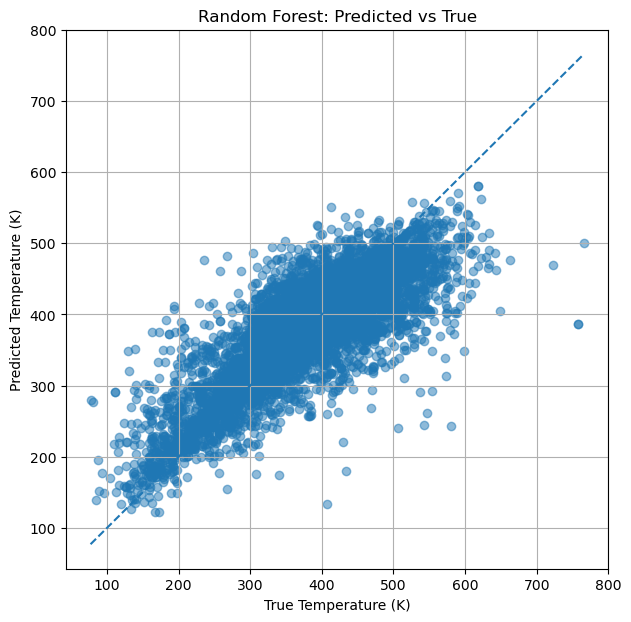

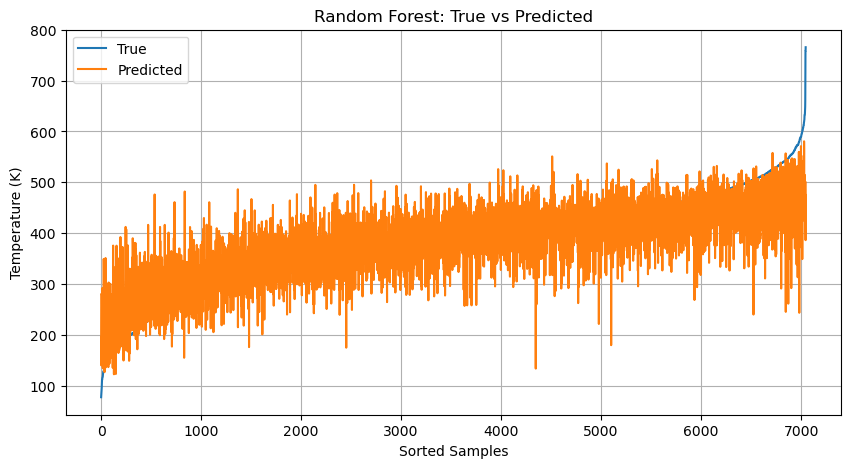

In [17]:
num_nodes = sum(tree.tree_.node_count for tree in model.estimators_)

print("Total nodes:", num_nodes)
print("Average nodes/tree:", num_nodes / len(model.estimators_))

# Flatten just in case
predictions = np.array(predictions).flatten()
Y_test = np.array(Y_test).flatten()

# Scatter plot
plt.figure(figsize=(7, 7))

plt.scatter(Y_test, predictions, alpha=0.5)

mn = min(Y_test.min(), predictions.min())
mx = max(Y_test.max(), predictions.max())

plt.plot([mn, mx], [mn, mx], linestyle="--")

plt.xlabel("True Temperature (K)")
plt.ylabel("Predicted Temperature (K)")
plt.title("Random Forest: Predicted vs True")

plt.grid(True)
plt.show()


# Sorted curves
order = np.argsort(Y_test)

plt.figure(figsize=(10, 5))

plt.plot(Y_test[order], label="True")
plt.plot(predictions[order], label="Predicted")

plt.xlabel("Sorted Samples")
plt.ylabel("Temperature (K)")
plt.title("Random Forest: True vs Predicted")
plt.legend()
plt.grid(True)

plt.show()